# ArtBench-10 Student Starter Pack

This notebook is a starting template for class projects using **ArtBench-10**.

It covers:

1. Loading ArtBench-10 from the local folder `artbench_generative_suite/ArtBench-10`
2. Exploring dataset shape and class distribution
3. Building PyTorch dataloaders
4. Visualizing samples in a grid
5. Exporting samples to image files (one image per file)
6. Loading subset definitions from `training.csv` generated by `generate_training_csv.py`


## Dataset quick notes

- **Domain**: paintings / artistic styles
- **Classes**: 10 styles
- **Image size**: 32x32 RGB
- **Splits**: train and test

In this project setup, dataset files are expected in:

- `ArtBench-10/artbench-10-python/artbench-10-batches-py/`
- `ArtBench-10/ArtBench-10.csv`

If you do not have it on the folder, download from kaggle directly:

https://www.kaggle.com/datasets/alexanderliao/artbench10


In [31]:
from __future__ import annotations

import sys
import random
from pathlib import Path
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.utils import make_grid, save_image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch.nn.functional as F

In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Relative paths (run this notebook from student_start_pack/)
PROJECT_ROOT = Path('..')
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
KAGGLE_ROOT = PROJECT_ROOT / 'ArtBench-10'

if not KAGGLE_ROOT.exists() or not (SCRIPTS_DIR / 'artbench_local_dataset.py').exists():
    raise FileNotFoundError(
        'Could not resolve project folders from relative paths. '
        'Run this notebook from student_start_pack/ or adjust PROJECT_ROOT.'
    )

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

print('PROJECT_ROOT =', PROJECT_ROOT)
print('KAGGLE_ROOT  =', KAGGLE_ROOT)

PROJECT_ROOT = ..
KAGGLE_ROOT  = ../ArtBench-10


In [3]:
# Uses your existing project helper to load ArtBench-10 from local Kaggle-style files
from artbench_local_dataset import load_kaggle_artbench10_splits

hf_ds = load_kaggle_artbench10_splits(KAGGLE_ROOT)
train_hf = hf_ds["train"]

print("Train size:", len(train_hf))
print("Columns   :", train_hf.column_names)

label_feature = train_hf.features["label"]
class_names = list(label_feature.names)
num_classes = len(class_names)
print("Num classes:", num_classes)
print("Class names:", class_names)

Dataset source: kaggle root='../ArtBench-10'
Train size: 50000
Columns   : ['image', 'label']
Num classes: 10
Class names: ['impressionism', 'realism', 'romanticism', 'expressionism', 'baroque', 'post_impressionism', 'art_nouveau', 'surrealism', 'ukiyo_e', 'renaissance']


In [4]:
# Class distribution summary
train_counts = Counter(train_hf["label"])

print("\nTrain class distribution:")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {train_counts.get(cid, 0):6d}")


Train class distribution:
   0 |   impressionism |   5000
   1 |         realism |   5000
   2 |     romanticism |   5000
   3 |   expressionism |   5000
   4 |         baroque |   5000
   5 | post_impressionism |   5000
   6 |     art_nouveau |   5000
   7 |      surrealism |   5000
   8 |         ukiyo_e |   5000
   9 |     renaissance |   5000


## Build PyTorch datasets and dataloaders

You can change:

- `IMAGE_SIZE` (default 32)
- `BATCH_SIZE`
- `TRAIN_FRACTION` if you want to train on a subset

In [5]:
IMAGE_SIZE = 32
BATCH_SIZE = 64
NUM_WORKERS = 2

def safe_num_workers(requested: int) -> int:
    # Avoid notebook multiprocessing pickling issues on macOS/ipykernel.
    if "ipykernel" in sys.modules and int(requested) > 0:
        print("Notebook kernel detected: forcing num_workers=0 for DataLoader stability.")
        return 0
    return int(requested)

EFFECTIVE_NUM_WORKERS = safe_num_workers(NUM_WORKERS)
TRAIN_FRACTION = 1.0  # Example: 0.5 means half of train split

transform = T.Compose([
    T.Resize(IMAGE_SIZE, interpolation=T.InterpolationMode.BILINEAR),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),  # outputs [0,1]
])


class HFDatasetTorch(Dataset):
    def __init__(self, hf_split, transform=None, indices=None):
        self.ds = hf_split
        self.transform = transform
        self.indices = list(range(len(hf_split))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        ex = self.ds[real_idx]
        img = ex["image"]
        y = int(ex["label"])
        x = self.transform(img) if self.transform else img
        return x, y, real_idx


def make_subset_indices(n_total: int, fraction: float, seed: int = 42):
    n_keep = max(1, int(round(n_total * fraction)))
    g = np.random.RandomState(seed)
    idx = np.arange(n_total)
    g.shuffle(idx)
    return idx[:n_keep].tolist()


train_indices = make_subset_indices(len(train_hf), TRAIN_FRACTION, seed=SEED)

train_ds = HFDatasetTorch(train_hf, transform=transform, indices=train_indices)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print("Train dataset length (after fraction):", len(train_ds))
print("Train batches                        :", len(train_loader))

Notebook kernel detected: forcing num_workers=0 for DataLoader stability.
Train dataset length (after fraction): 50000
Train batches                        : 782


## Load subset of 20% samples `training_20_percent.csv` 

you can reproduce the same subset in this notebook by loading IDs from that CSV.

Use `train_id_original` for indexing this notebook's full train split.


In [6]:
import csv

#warning if using colab kernel on vscode you need to put the files on your google drive and link this notebook to it.
TRAINING_CSV_PATH = Path('training_20_percent.csv')
INDEX_COLUMN = 'train_id_original'  # recommended 


def load_ids_from_training_csv(csv_path: Path, index_column: str = "train_id_original") -> list[int]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(
            f"training.csv not found: {csv_path}\n"
            "Generate it first with scripts/generate_training_csv.py"
        )

    ids = []
    with open(csv_path, 'r', encoding='utf-8', newline='') as f:
        r = csv.DictReader(f)
        if index_column not in (r.fieldnames or []):
            raise ValueError(
                f"Column {index_column!r} not present in {csv_path}. "
                f"Available: {r.fieldnames}"
            )
        for row in r:
            v = str(row.get(index_column, "")).strip()
            if v == "":
                continue
            ids.append(int(v))

    if len(ids) == 0:
        raise ValueError(f"No ids found in {csv_path} column {index_column!r}")
    return ids


train_ids_from_csv = load_ids_from_training_csv(TRAINING_CSV_PATH, index_column=INDEX_COLUMN)
print('Loaded ids:', len(train_ids_from_csv))
print('First 10 ids:', train_ids_from_csv[:10])

# Build a train dataset/loader using exactly those IDs
train_ds_from_csv = HFDatasetTorch(train_hf, transform=transform, indices=train_ids_from_csv)
train_loader_from_csv = DataLoader(
    train_ds_from_csv,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=EFFECTIVE_NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print('Subset train dataset length:', len(train_ds_from_csv))
print('Subset train batches      :', len(train_loader_from_csv))


Loaded ids: 10000
First 10 ids: [33553, 9427, 199, 12447, 39489, 42724, 10822, 49498, 4144, 36958]
Subset train dataset length: 10000
Subset train batches      : 157


In [7]:
subset_labels = [train_hf["label"][i] for i in train_ids_from_csv]
subset_counts = Counter(subset_labels)

print("\nTrain class distribution: (20% Excel):")
for cid, name in enumerate(class_names):
    print(f"  {cid:2d} | {name:>15s} | {subset_counts.get(cid, 0):6d}")


Train class distribution: (20% Excel):
   0 |   impressionism |    995
   1 |         realism |   1003
   2 |     romanticism |    955
   3 |   expressionism |   1017
   4 |         baroque |    998
   5 | post_impressionism |   1013
   6 |     art_nouveau |   1019
   7 |      surrealism |   1009
   8 |         ukiyo_e |    983
   9 |     renaissance |   1008


## Visualize a sample grid

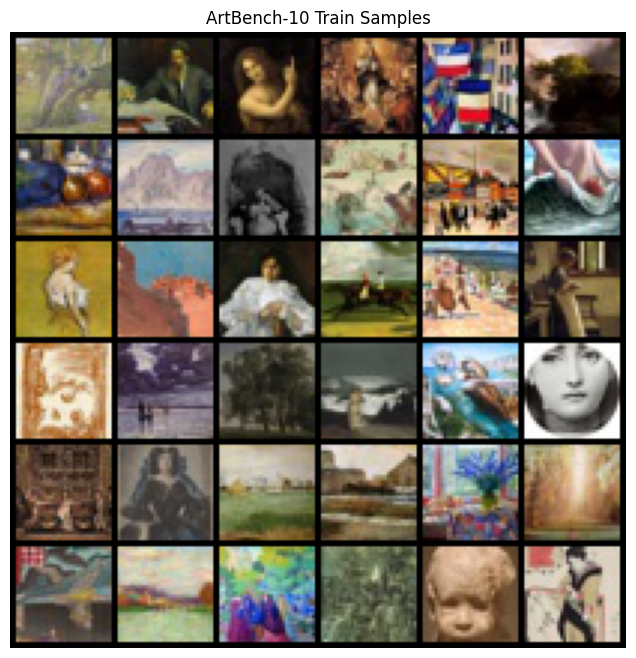

Labels: ['impressionism', 'realism', 'renaissance', 'baroque', 'post_impressionism', 'romanticism', 'post_impressionism', 'art_nouveau', 'romanticism', 'ukiyo_e', 'post_impressionism', 'surrealism', 'post_impressionism', 'realism', 'impressionism', 'romanticism', 'expressionism', 'realism', 'expressionism', 'post_impressionism', 'romanticism', 'realism', 'surrealism', 'surrealism', 'renaissance', 'realism', 'impressionism', 'impressionism', 'realism', 'impressionism', 'ukiyo_e', 'impressionism', 'art_nouveau', 'renaissance', 'post_impressionism', 'ukiyo_e']


In [12]:
def show_batch_grid(loader, class_names, n_images=36, nrow=6, title='Sample Grid'):
    x, y, idx = next(iter(loader))
    x = x[:n_images]
    y = y[:n_images]

    grid = make_grid(x, nrow=nrow, padding=2)
    np_img = grid.permute(1, 2, 0).cpu().numpy()

    plt.figure(figsize=(8, 8))
    plt.imshow(np_img)
    plt.axis('off')
    plt.title(title)
    plt.show()

    # Print labels for quick inspection
    labels_str = [class_names[int(v)] for v in y]
    print('Labels:', labels_str)


show_batch_grid(train_loader, class_names, n_images=36, nrow=6, title='ArtBench-10 Train Samples')

## Export samples to image files

This helper saves one PNG per sample and writes a CSV with metadata.
Useful for qualitative analysis or external metric tools.

In [10]:
import csv


def export_split_to_folder(
    loader: DataLoader,
    class_names: list[str],
    out_dir: Path,
    max_images: int | None = 500,
):
    out_dir = Path(out_dir)
    img_dir = out_dir / 'images'
    img_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    saved = 0

    for x, y, idx in loader:
        b = x.shape[0]
        for i in range(b):
            if max_images is not None and saved >= max_images:
                break

            label_id = int(y[i].item())
            label_name = class_names[label_id]
            src_idx = int(idx[i].item())

            file_name = f"img_{saved:06d}_label{label_id:02d}_idx{src_idx:06d}.png"
            path = img_dir / file_name
            save_image(x[i], path)

            rows.append({
                'file_name': file_name,
                'label_id': label_id,
                'label_name': label_name,
                'source_index': src_idx,
            })
            saved += 1

        if max_images is not None and saved >= max_images:
            break

    csv_path = out_dir / 'metadata.csv'
    with open(csv_path, 'w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=['file_name', 'label_id', 'label_name', 'source_index'])
        w.writeheader()
        w.writerows(rows)

    print(f'Exported {saved} images to: {img_dir}')
    print(f'Metadata CSV: {csv_path}')


EXPORT_ROOT = Path('exported_data')
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

export_split_to_folder(train_loader, class_names, EXPORT_ROOT / 'train_subset', max_images=500)


Exported 500 images to: exported_data/train_subset/images
Metadata CSV: exported_data/train_subset/metadata.csv


## Notebook Setup


In [17]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('Device:', device)

Device: mps


In [31]:
def plot_batch_examples(loader, title='Samples', n_show=16):
    # O loader do ArtBench retorna (imagens, labels, indices)
    x, y, _ = next(iter(loader)) 
    
    n_show = min(n_show, x.size(0))
    rows = int(np.sqrt(n_show)) 
    cols = int(np.ceil(n_show / rows))

    fig, axes = plt.subplots(rows, cols, figsize=(1.8 * cols, 1.8 * rows))
    axes = np.array(axes).reshape(rows, cols)
    
    for i in range(rows * cols): 
        ax = axes[i // cols, i % cols]
        if i < n_show:
            # Adaptado para RGB: permute(1, 2, 0) muda de [C, H, W] para [H, W, C]
            img = x[i].permute(1, 2, 0).cpu().numpy()
            
            # Se a imagem estiver normalizada (ex: entre -1 e 1), desfazemos para [0, 1]
            if img.min() < 0:
                img = (img + 1) / 2
                
            ax.imshow(img.clip(0, 1))
            
            # Título com o nome da classe se disponível, senão o ID
            label_name = class_names[int(y[i])] if 'class_names' in globals() else int(y[i])
            ax.set_title(f'{label_name}', fontsize=8)
        ax.axis('off')
        
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# Autoencoders

## Dense AE

```text
input: x (batch of images)
x_flat = flatten(x)
z = Encoder(x_flat)
x_hat = Decoder(z)
L_recon = BCE(x_hat, x_flat)
update parameters with backprop
```

O tamanho da imagem no ArtBench-10 é diferente do MNIST, logo no input_dim:
- MNIST: 784 ($28 \times 28 \times 1$)
- ArtBench-10: 3072 ($32 \times 32 \times 3$ canais RGB).

Como a entrada agora é muito maior (3072 em vez de 784), aumentamos também as camadas escondidas (hidden_dims) para o modelo ter espaço para aprender as cores e os detalhes das pinturas. Logicamente, hidden_dims tem de ser menor que input_dim e a hidden 1 maior que a hidden 2. Também se deve ter em conta que um latent_dim muito baixo guarda apenas formas muito básicas e se for muito alto copia os pixeis e não aprende, podendo perder o efeito de compressão. PPor fim, se metermos valores de hidden_dims e latent_dim muito elevados, exigirá muito poder computacional.


In [57]:
class DenseAutoencoder(nn.Module):
    def __init__(self, input_dim=784, hidden_dims=(1024, 512), latent_dim=64):
        super(DenseAutoencoder, self).__init__()
        
        self.input_dim = input_dim
        self.hidden_dims = hidden_dims
        self.latent_dim = latent_dim
        
        #Encoder
        self.encoder = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dims[0]),
            nn.ReLU(), #minimize the errors between the layers
            nn.Linear(self.hidden_dims[0], self.hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(self.hidden_dims[1], self.latent_dim)
            )
        
        
        #Decoder
        self.decoder = nn.Sequential(
            nn.Linear(self.latent_dim, self.hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(self.hidden_dims[1], self.hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(self.hidden_dims[0], self.input_dim),
            nn.Sigmoid()
        )


    def forward(self, x):
        return self.decoder(self.encoder(x))

In [14]:
def train_autoencoder(model, loader, optimizer, epochs=20, flatten_input=True):
    model.train()
    history = []
    for ep in range(epochs):
        run = 0.0
        ## ALTERAÇÃO: o ArtBench retorna (imagem, label, índice)
        for x, _, _ in tqdm(loader, leave=False):
            x = x.to(device) 
            xin = x.view(x.size(0), -1) if flatten_input else x
            # TODO START
            xhat = model(xin)
            loss = F.binary_cross_entropy(xhat, xin, reduction='sum')/x.size(0)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # TODO END
            run += loss.item() * x.size(0)
        epoch_recon = run / len(loader.dataset)
        history.append({'train_recon_bce': epoch_recon})
        print(f'Epoch {ep+1}/{epochs} | train_recon_bce={epoch_recon:.4f}')
    return history


def evaluate_autoencoder(model, loader, flatten_input=True):
    model.eval()
    tb, tm, ta, n = 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        for x, _, _ in loader:
            x = x.to(device)
            xin = x.view(x.size(0), -1) if flatten_input else x
            xhat = model(xin)
            b = x.size(0)
            # TODO START
            tb += F.binary_cross_entropy(xhat, xin, reduction='sum').item()
            tm += F.mse_loss(xhat, xin, reduction='sum').item()
            ta += F.l1_loss(xhat, xin, reduction='sum').item()  
            n += b
            # TODO END
    numel = xin[0].numel()
    return {'bce': tb/n, 'mse': tm/(n*numel), 'mae': ta/(n*numel)}


In [15]:
import json

def fit_or_load_model(model, run_name, train_fn, load_if_available=True, **train_kwargs):
    # Define onde guardar o modelo (.pth) e o histórico (.json)
    model_path = Path(f"{run_name}.pth")
    history_path = Path(f"{run_name}_history.json")

    # Se já existir e quisermos carregar:
    if load_if_available and model_path.exists():
        model.load_state_dict(torch.load(model_path, map_location=device))
        with open(history_path, 'r') as f:
            history = json.load(f)
        print(f'Modelo carregado de: {model_path}')
        return history

    # Se não existir, treina do zero:
    history = train_fn(model=model, **train_kwargs)
    
    # Guarda o modelo e o histórico para a próxima vez
    torch.save(model.state_dict(), model_path)
    with open(history_path, 'w') as f:
        json.dump(history, f)
    print(f'Treino concluído e guardado em: {model_path}')
    return history

In [56]:
# TODO START
EPOCHS_ONE = 20
input_size = 32 * 32 * 3  # = 3072 (ArtBench)
USE_SAVED_MODELS_IF_AVAILABLE = True

# CORREÇÃO: Passar o input_dim para o modelo
dense_all = DenseAutoencoder(input_dim=input_size, latent_dim=64).to(device)

opt_dense_all = torch.optim.Adam(dense_all.parameters(), lr=1e-3)
# TODO END

hist_dense_all = fit_or_load_model(
    model=dense_all,
    run_name='artbench_dense_ae_v1',      # Nome do ficheiro onde guarda o modelo
    train_fn=train_autoencoder,
    load_if_available=USE_SAVED_MODELS_IF_AVAILABLE, # Para não treinar sempre do zero
    loader=train_loader_from_csv,        # Os teus dados de 20%
    optimizer=opt_dense_all,
    epochs=EPOCHS_ONE,
    flatten_input=True                   # <--- FALTA ESTE: Necessário para Dense AE
)
metrics_dense_all = evaluate_autoencoder(dense_all, train_loader_from_csv, flatten_input=True)


Modelo carregado de: artbench_dense_ae_v1.pth


In [ ]:
def show_reconstructions(model, loader, flatten_input, title='Recon', n_show=8):
    model.eval()
    x, _, _ = next(iter(loader))
    x = x.to(device)
    xin = x.view(x.size(0), -1) if flatten_input else x
    with torch.no_grad():
        xhat = model(xin)
    if flatten_input:
        xhat = xhat.view(-1, 3, 32, 32) # Ajuste para ArtBench RGB 32x32

    x = x[:n_show].cpu().numpy()
    xhat = xhat[:n_show].cpu().numpy()

    fig, axes = plt.subplots(2, n_show, figsize=(1.5*n_show, 3.2))
    for i in range(n_show):
        axes[0, i].imshow(x[i, 0], cmap='gray')
        axes[1, i].imshow(xhat[i, 0], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('real')
    axes[1, 0].set_ylabel('recon')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_reconstructions_vae(model, loader, title='VAE recon', n_show=8):
    model.eval()
    x, _, _ = next(iter(loader))
    x = x.to(device)

    with torch.no_grad():
        xhat, _, _ = model(x)

    if x.dim() == 2:
        x = x.view(-1, 1, 28, 28)
    if xhat.dim() == 2:
        xhat = xhat.view(-1, 1, 28, 28)

    x = x[:n_show].cpu().numpy()
    xhat = xhat[:n_show].cpu().numpy()

    fig, axes = plt.subplots(2, n_show, figsize=(1.5*n_show, 3.2))
    for i in range(n_show):
        #axes[0, i].imshow(x[i, 0], cmap='gray')
        #axes[1, i].imshow(xhat[i, 0], cmap='gray')
        axes[0, i].imshow(x[i].transpose(1, 2, 0))
        axes[1, i].imshow(xhat[i].transpose(1, 2, 0))
        axes[0, i].axis('off')
        axes[1, i].axis('off')
    axes[0, 0].set_ylabel('real')
    axes[1, 0].set_ylabel('recon')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_epoch_metric(histories, metric_key, title, ylabel):
    plt.figure(figsize=(5.0, 3.5))
    for name, hist in histories.items():
        plt.plot(range(1, len(hist)+1), [h[metric_key] for h in hist], marker='o', label=name)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def report_autoencoder_metrics(name, history, metrics):
    print(f"[{name}] final train recon BCE: {history[-1]['train_recon_bce']:.4f}")
    print(f"[{name}] test metrics: {metrics}")


def report_vae_metrics(name, history, metrics):
    h = history[-1]
    print(f"[{name}] final train total: {h['train_loss']:.4f}")
    print(f"[{name}] final train recon: {h['train_recon_bce']:.4f}")
    print(f"[{name}] final train KL: {h['train_kl']:.4f}")
    print(f"[{name}] test metrics: {metrics}")


[Dense AE] final train recon BCE: 1790.9065
[Dense AE] test metrics: {'bce': 2129.568233984375, 'mse': 0.064844064950943, 'mae': 0.21734699141184488}


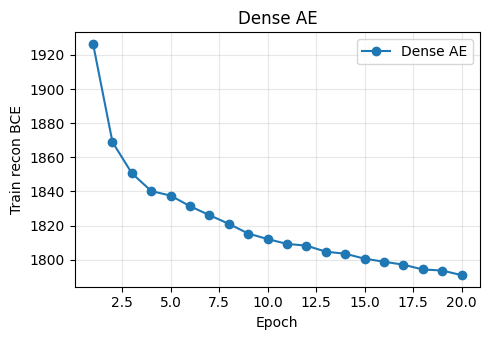

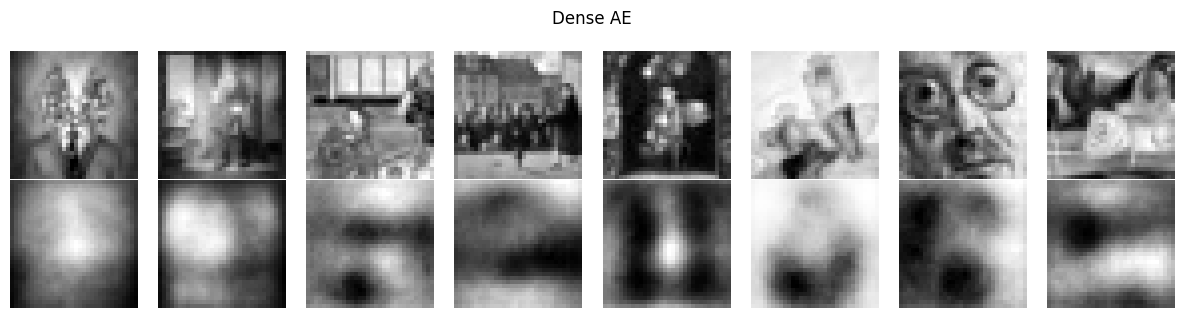

In [39]:
report_autoencoder_metrics('Dense AE', hist_dense_one, metrics_dense_one)
plot_epoch_metric({'Dense AE': hist_dense_one}, 'train_recon_bce', 'Dense AE', 'Train recon BCE')
show_reconstructions(dense_one, train_loader_from_csv, flatten_input=True, title='Dense AE')

## Convolutional AE

```text
input: x with shape [B, 1, 28, 28]
z = ConvEncoder(x)
x_hat = ConvDecoder(z)
L_recon = BCE(x_hat, x)
update parameters with backprop
```

In [58]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.latent_dim = latent_dim
        # TODO START
        self.enc_conv = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), 
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1), 
            nn.ReLU()
        )
        self.enc_fc = nn.Linear(128*8*8, self.latent_dim)
        self.dec_fc = nn.Linear(self.latent_dim, 128*8*8)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        #raise NotImplementedError('Implement ConvAutoencoder layers from the recipe')
        # TODO END

    def encode(self, x):
        h = self.enc_conv(x)
        return self.enc_fc(h.view(h.size(0), -1))

    def decode(self, z):
        h = self.dec_fc(z).view(-1, 128, 8, 8)
        return self.dec_conv(h)

    def forward(self, x):
        return self.decode(self.encode(x))


In [36]:
# TODO START
EPOCHS_ALL_CONV = 20
conv_all = ConvAutoencoder(latent_dim=64).to(device)
opt_conv_all = torch.optim.Adam(conv_all.parameters(), lr=1e-3)
# TODO END

hist_conv_all = fit_or_load_model(
    model=conv_all,
    run_name='artbench_conv_ae_v1',
    train_fn=train_autoencoder,
    load_if_available=USE_SAVED_MODELS_IF_AVAILABLE,
    loader=train_loader_from_csv,
    optimizer=opt_conv_all,
    epochs=EPOCHS_ALL_CONV,
    flatten_input=False,
)
metrics_conv_all = evaluate_autoencoder(conv_all, train_loader_from_csv, flatten_input=False)


  0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1/20 | train_recon_bce=1901.3491


  0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2/20 | train_recon_bce=1794.3434


  0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 18/20 | train_recon_bce=1740.8000


  0%|          | 0/157 [00:00<?, ?it/s]

Epoch 19/20 | train_recon_bce=1740.4733


  0%|          | 0/157 [00:00<?, ?it/s]

Epoch 20/20 | train_recon_bce=1740.3935
Treino concluído e guardado em: artbench_conv_ae_v1.pth


[Dense AE] final train recon BCE: 1790.9065
[Dense AE] test metrics: {'bce': 2129.67483828125, 'mse': 0.06486141508420308, 'mae': 0.21737808809280396}
[Convolutional AE] final train recon BCE: 1740.3935
[Convolutional AE] test metrics: {'bce': 1739.65243359375, 'mse': 0.007544596187273662, 'mae': 0.06257520747979482}


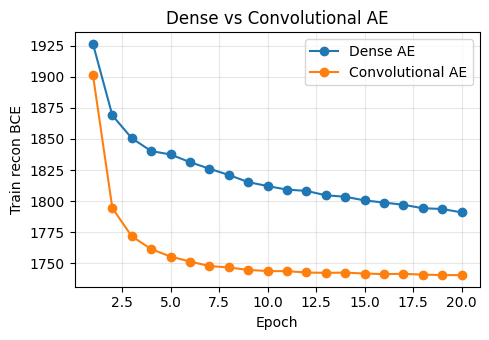

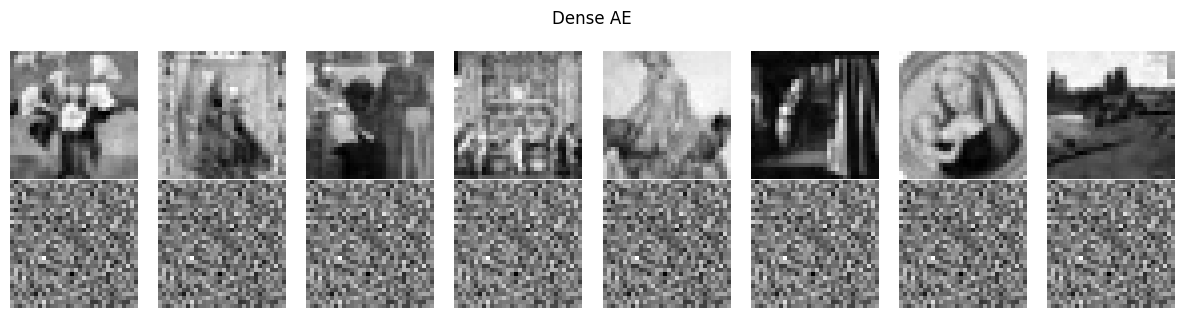

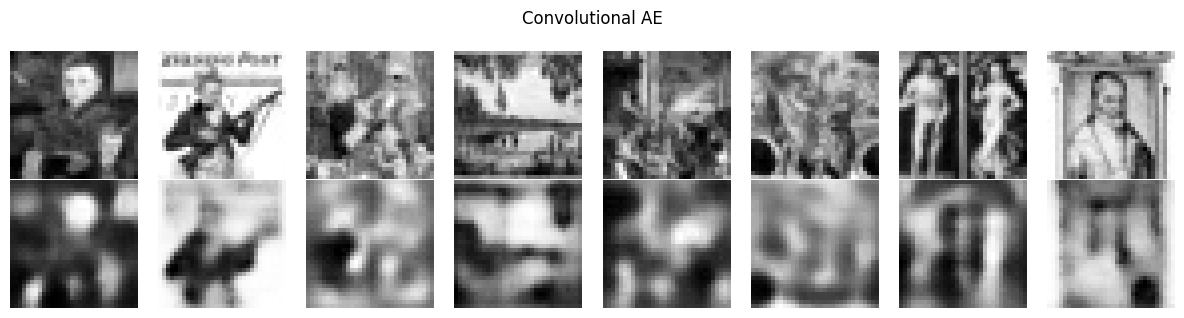

In [42]:
report_autoencoder_metrics('Dense AE', hist_dense_all, metrics_dense_all)
report_autoencoder_metrics('Convolutional AE', hist_conv_all, metrics_conv_all)

plot_epoch_metric(
    {'Dense AE': hist_dense_all, 'Convolutional AE': hist_conv_all},
    'train_recon_bce',
    'Dense vs Convolutional AE',
    'Train recon BCE'
)

show_reconstructions(dense_all, train_loader_from_csv, flatten_input=True, title='Dense AE')
show_reconstructions(conv_all, train_loader_from_csv, flatten_input=False, title='Convolutional AE')


### Latent traversal setup (Dense + Convolutional)

In [59]:
def artbench_dense_decoder(z_2d):
    latent_dim = 64
    z_full = torch.zeros(z_2d.size(0), latent_dim, device=device)
    z_full[:, :2] = z_2d
    return dense_all.decoder(z_full)

def artbench_conv_decoder(z_2d):
    latent_dim = 64
    z_full = torch.zeros(z_2d.size(0), latent_dim, device=device)
    z_full[:, :2] = z_2d
    return conv_all.decode(z_full)

In [47]:
def plot_latent_traversal(decoder_fn, title='Latent traversal', n_samples=200, low=-2.5, high=2.5):
    grid = int(np.sqrt(n_samples))
    n_rows, n_cols = grid, grid
    z1 = torch.linspace(low, high, n_cols)
    z2 = torch.linspace(low, high, n_rows)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.2*n_cols, 1.2*n_rows))
    with torch.no_grad():
        for i, yy in enumerate(z2):
            for j, xx in enumerate(z1):
                z = torch.tensor([[xx, yy]], dtype=torch.float32, device=device)
                xhat = decoder_fn(z)
                if xhat.dim() == 2:
                    xhat = xhat.view(-1, 3, 32, 32)
                img = xhat[0, 0].detach().cpu().numpy()
                axes[i, j].imshow(img, cmap='gray', vmin=0, vmax=1)
                axes[i, j].axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


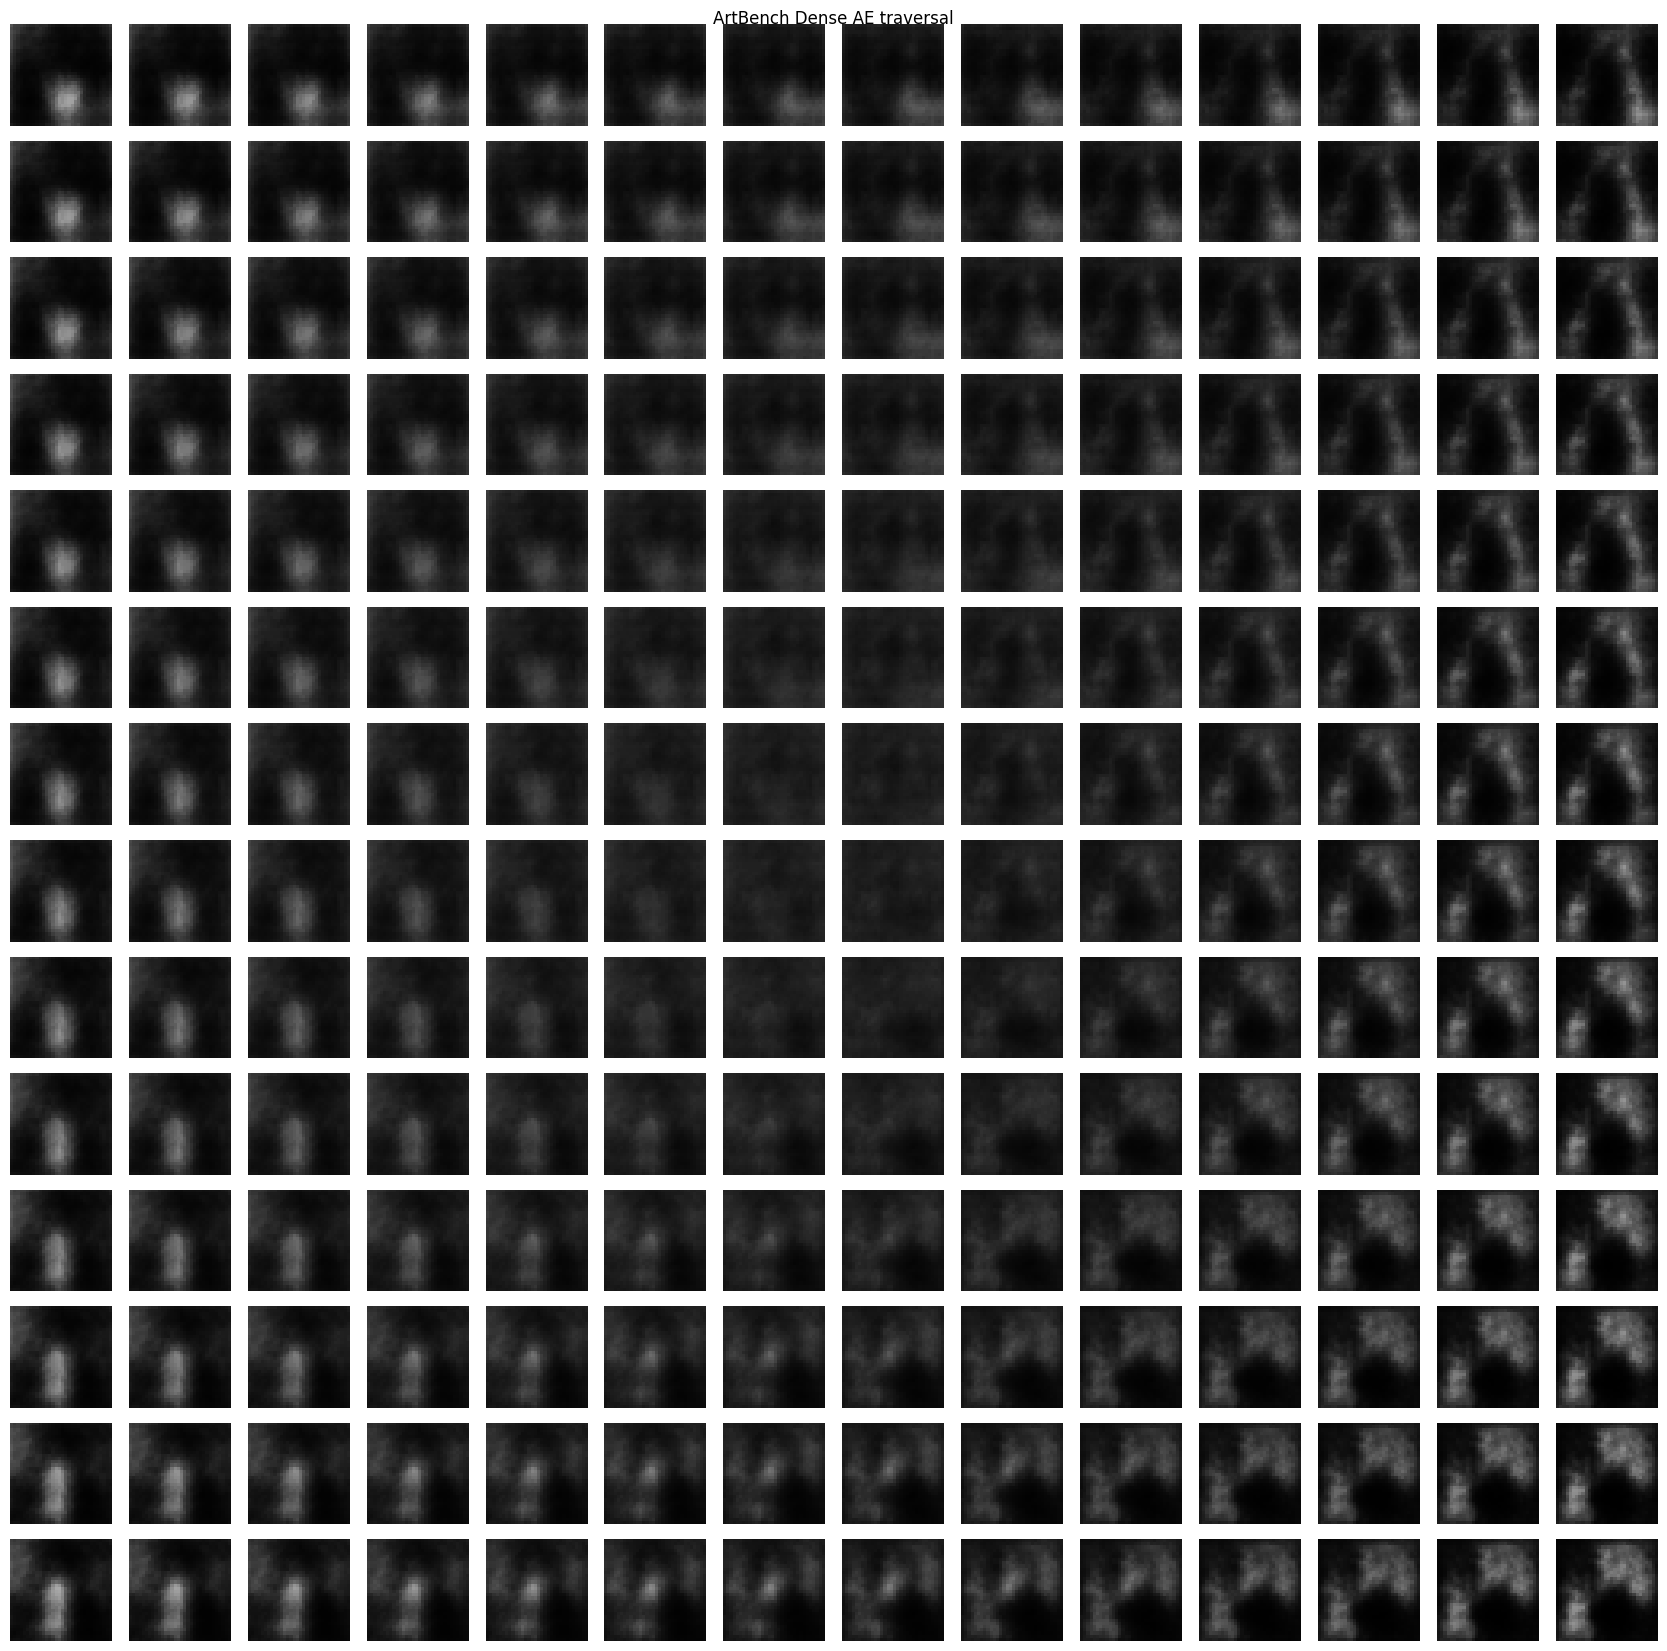

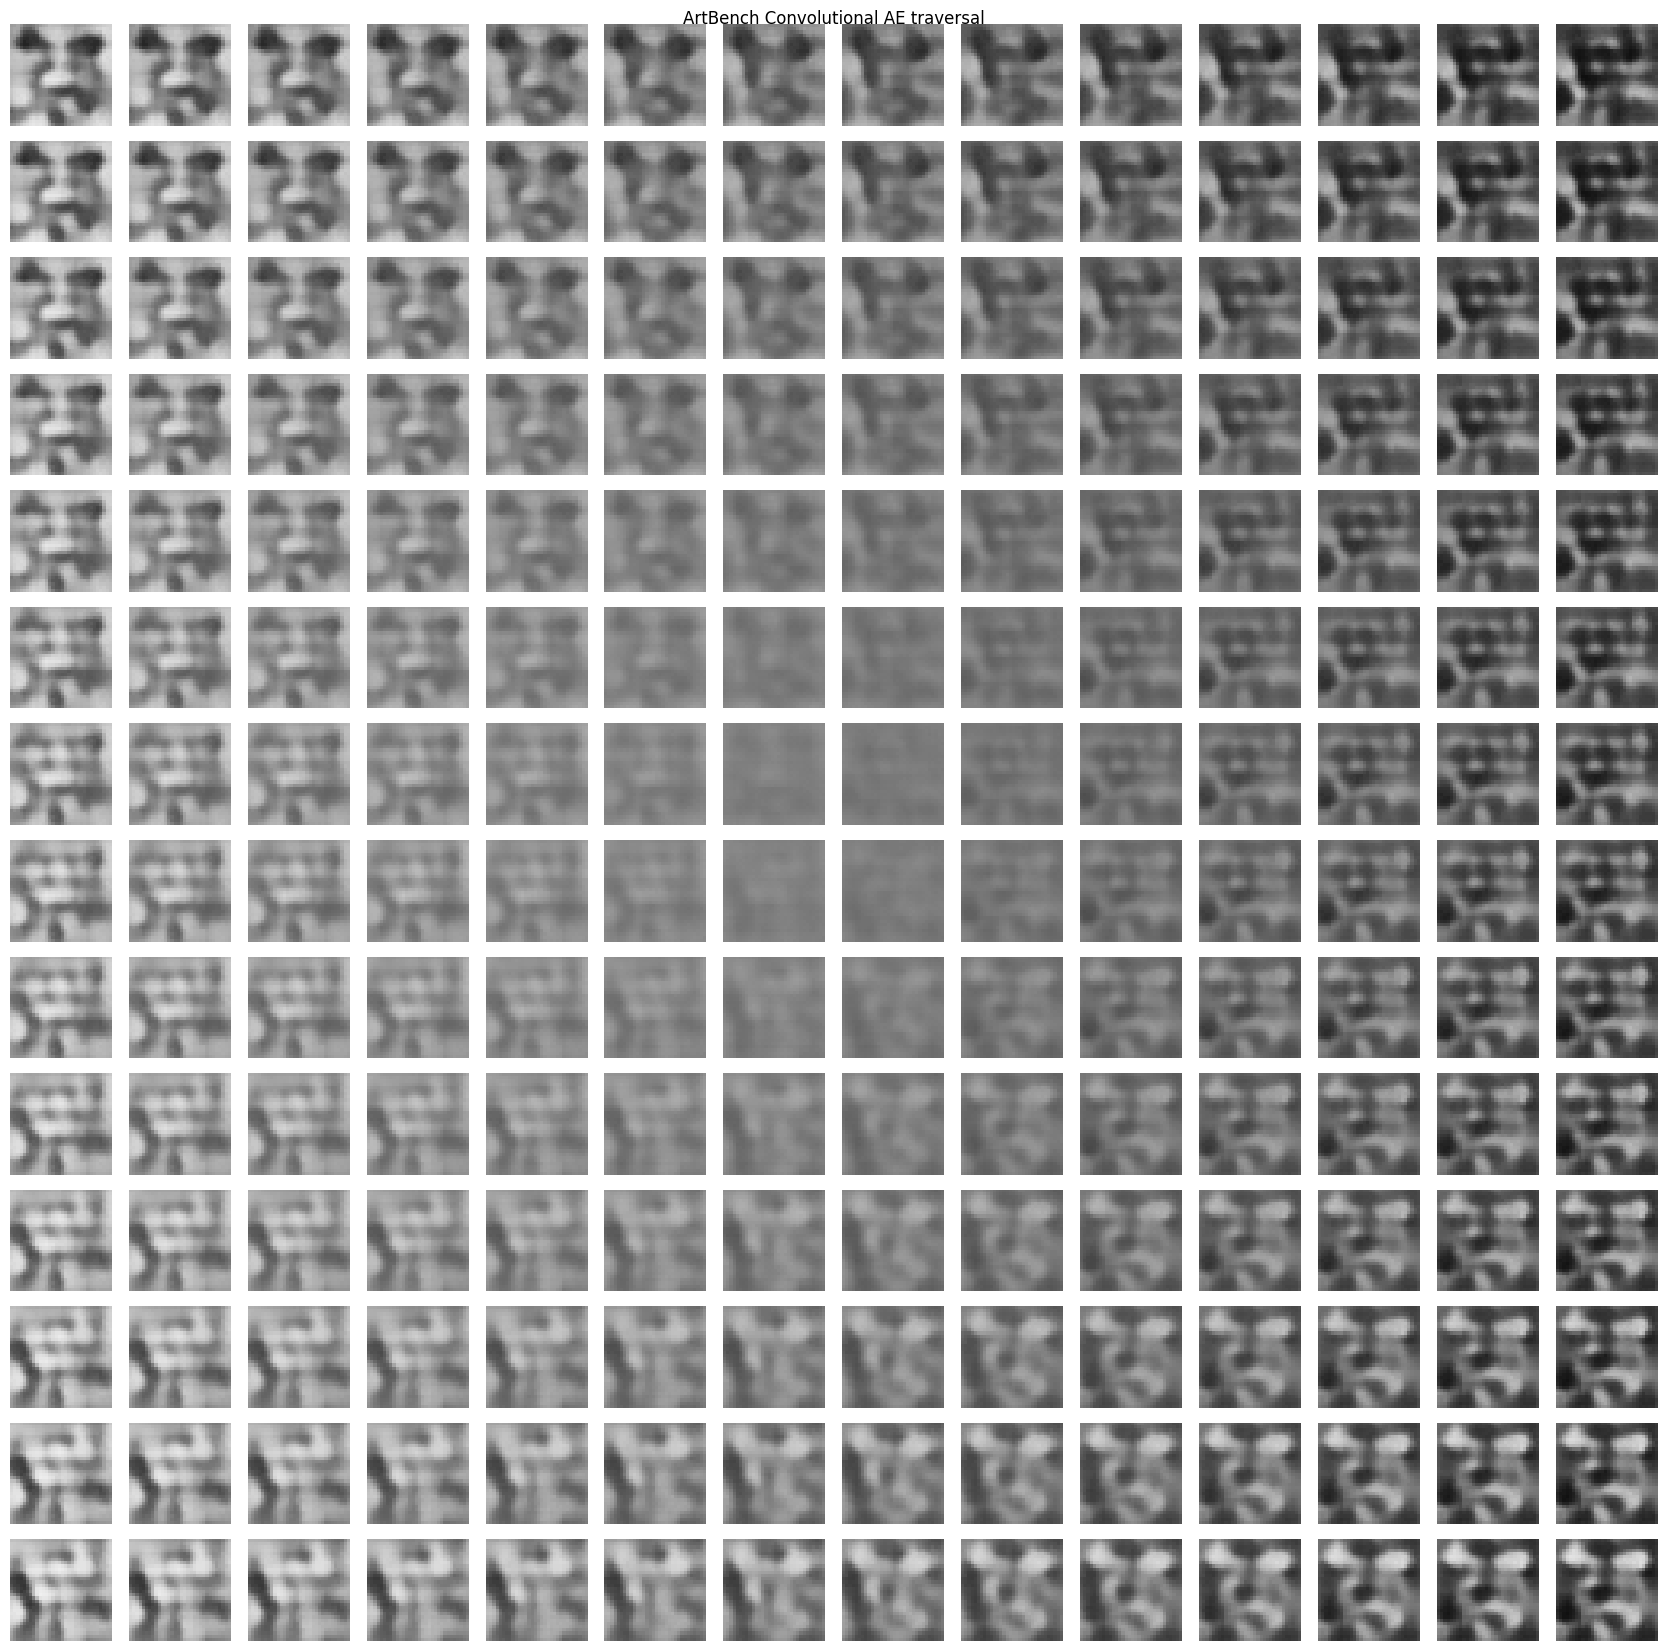

In [60]:
plot_latent_traversal(artbench_dense_decoder, title='ArtBench Dense AE traversal', n_samples=200)
plot_latent_traversal(artbench_conv_decoder, title='ArtBench Convolutional AE traversal', n_samples=200)

## Convolutional VAE

In [77]:
class ConvVAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim

        self.enc_conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        # TODO START
        self.fc_mu = nn.Linear(128*8*8, latent_dim)
        self.fc_logvar = nn.Linear(128*8*8, latent_dim)
        # Add mean and log-variance heads from flattened conv features.
        #raise NotImplementedError('Implement ConvVAE latent heads')
        # TODO END

        self.dec_fc = nn.Linear(latent_dim, 128 * 8 * 8)
        self.dec_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.enc_conv(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        # TODO START
        eps = torch.randn_like(logvar)
        z = mu + eps * torch.exp(logvar * 0.5)
        return z
        #raise NotImplementedError('Implement reparameterization')
        # TODO END

    def decode(self, z):
        h = self.dec_fc(z).view(-1, 128, 8, 8)
        return self.dec_conv(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        xhat = self.decode(z)
        return xhat, mu, logvar


In [78]:
def vae_loss(xhat, x, mu, logvar, beta=0.7):
    # TODO START
    recon = F.binary_cross_entropy(xhat, x, reduction='sum')/x.size(0) 
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())/x.size(0)
    loss = recon + beta * kl
    return loss, recon, kl
    #raise NotImplementedError('Implement VAE loss')
    # TODO END


def train_vae(model, loader, optimizer, epochs=20, beta=0.7):
    model.train()
    hist = []
    for ep in range(epochs):
        tl, tr, tk = 0.0, 0.0, 0.0
        for x, _, _ in tqdm(loader, leave=False):
            x = x.to(device)
            # TODO START
            xhat, mu, logvar = model(x)
            loss, recon, kl = vae_loss(xhat, x, mu, logvar, beta=beta)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            #raise NotImplementedError('Implement VAE training step')
            # TODO END
            tl += loss.item() * x.size(0)
            tr += recon.item() * x.size(0)
            tk += kl.item() * x.size(0)
        n = len(loader.dataset)
        hist.append({'train_loss': tl/n, 'train_recon_bce': tr/n, 'train_kl': tk/n})
        print(f'Epoch {ep+1}/{epochs} | train_loss={tl/n:.4f} train_recon={tr/n:.4f} train_kl={tk/n:.4f}')
    return hist


def evaluate_vae(model, loader, beta=0.7):
    model.eval()
    tl, tr, tk, tm, ta, n = 0.0, 0.0, 0.0, 0.0, 0.0, 0
    with torch.no_grad():
        for x, _, _ in loader:
            x = x.to(device)
            xhat, mu, logvar = model(x)
            b = x.size(0)
            loss, recon, kl = vae_loss(xhat, x, mu, logvar, beta=beta)
            # TODO START
            tl += loss.item() * b
            tr += recon.item() * b
            tk += kl.item() * b
            tm += F.mse_loss(xhat, x, reduction='sum').item()
            ta += F.l1_loss(xhat, x, reduction='sum').item()
            n += b
            #raise NotImplementedError('Implement VAE evaluation loop')
            # TODO END
    numel = x[0].numel()
    return {'loss': tl/n, 'recon_bce': tr/n, 'kl': tk/n, 'mse': tm/(n*numel), 'mae': ta/(n*numel)}


In [79]:
# TODO START
vae_all = None
opt_vae_all = None
EPOCHS_VAE_ALL = 20  
BETA_VAE_ALL = 0.5    # Um beta ligeiramente mais baixo ajuda na nitidez das cores

vae_all = ConvVAE(latent_dim=128).to(device)

# Otimizador Adam com a learning rate padrão
opt_vae_all = torch.optim.Adam(vae_all.parameters(), lr=1e-3)
# TODO END

hist_vae_all = fit_or_load_model(
    model=vae_all,
    run_name='artbench_all_conv_vae', 
    train_fn=train_vae,
    load_if_available=USE_SAVED_MODELS_IF_AVAILABLE,
    loader=train_loader_from_csv,
    optimizer=opt_vae_all,
    epochs=EPOCHS_VAE_ALL,
    beta=BETA_VAE_ALL,
)

metrics_vae_all = evaluate_vae(vae_all, train_loader_from_csv, beta=BETA_VAE_ALL) #aqui devia ser test_loader

Modelo carregado de: artbench_all_conv_vae.pth


[VAE] final train total: 0.0341
[VAE] final train recon: 0.0107
[VAE] final train KL: 0.0468
[VAE] test metrics: {'loss': 2101.494855859375, 'recon_bce': 2101.486532421875, 'kl': 0.01664105513095856, 'mse': 0.06030982900460561, 'mae': 0.208175887298584}


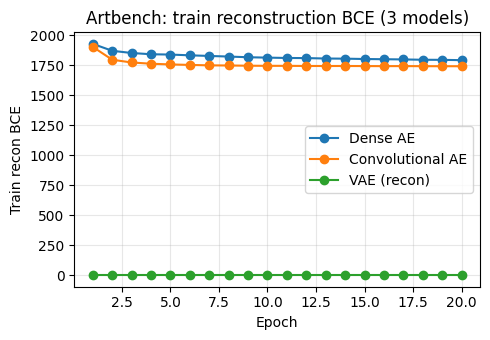

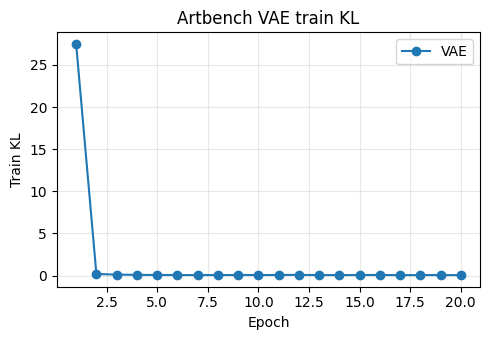

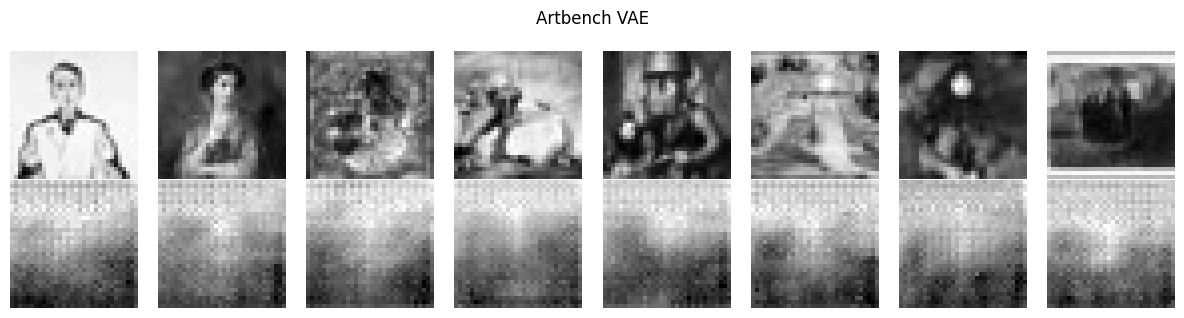

=== Artbench comparison ===
Dense AE: {'bce': 1789.268104296875, 'mse': 0.014253327379624049, 'mae': 0.0879739906946818}
Convolutional AE: {'bce': 1739.65243359375, 'mse': 0.007544596187273662, 'mae': 0.06257520747979482}
VAE: {'loss': 2101.494855859375, 'recon_bce': 2101.486532421875, 'kl': 0.01664105513095856, 'mse': 0.06030982900460561, 'mae': 0.208175887298584}


In [80]:
report_vae_metrics('VAE', hist_vae_all, metrics_vae_all)
plot_epoch_metric(
    {'Dense AE': hist_dense_all, 'Convolutional AE': hist_conv_all, 'VAE (recon)': hist_vae_all},
    'train_recon_bce',
    'Artbench: train reconstruction BCE (3 models)',
    'Train recon BCE'
)
plot_epoch_metric({'VAE': hist_vae_all}, 'train_kl', 'Artbench VAE train KL', 'Train KL')
show_reconstructions_vae(vae_all, train_loader_from_csv, title='Artbench VAE') #Aqui devia ser test

print('=== Artbench comparison ===')
print('Dense AE:', metrics_dense_all)
print('Convolutional AE:', metrics_conv_all)
print('VAE:', metrics_vae_all)

In [81]:
artbench_vae_decoder = lambda z_2d: vae_all.decode(torch.cat([z_2d, torch.zeros(z_2d.size(0), vae_all.latent_dim - 2, device=device)], dim=1))# TODO END

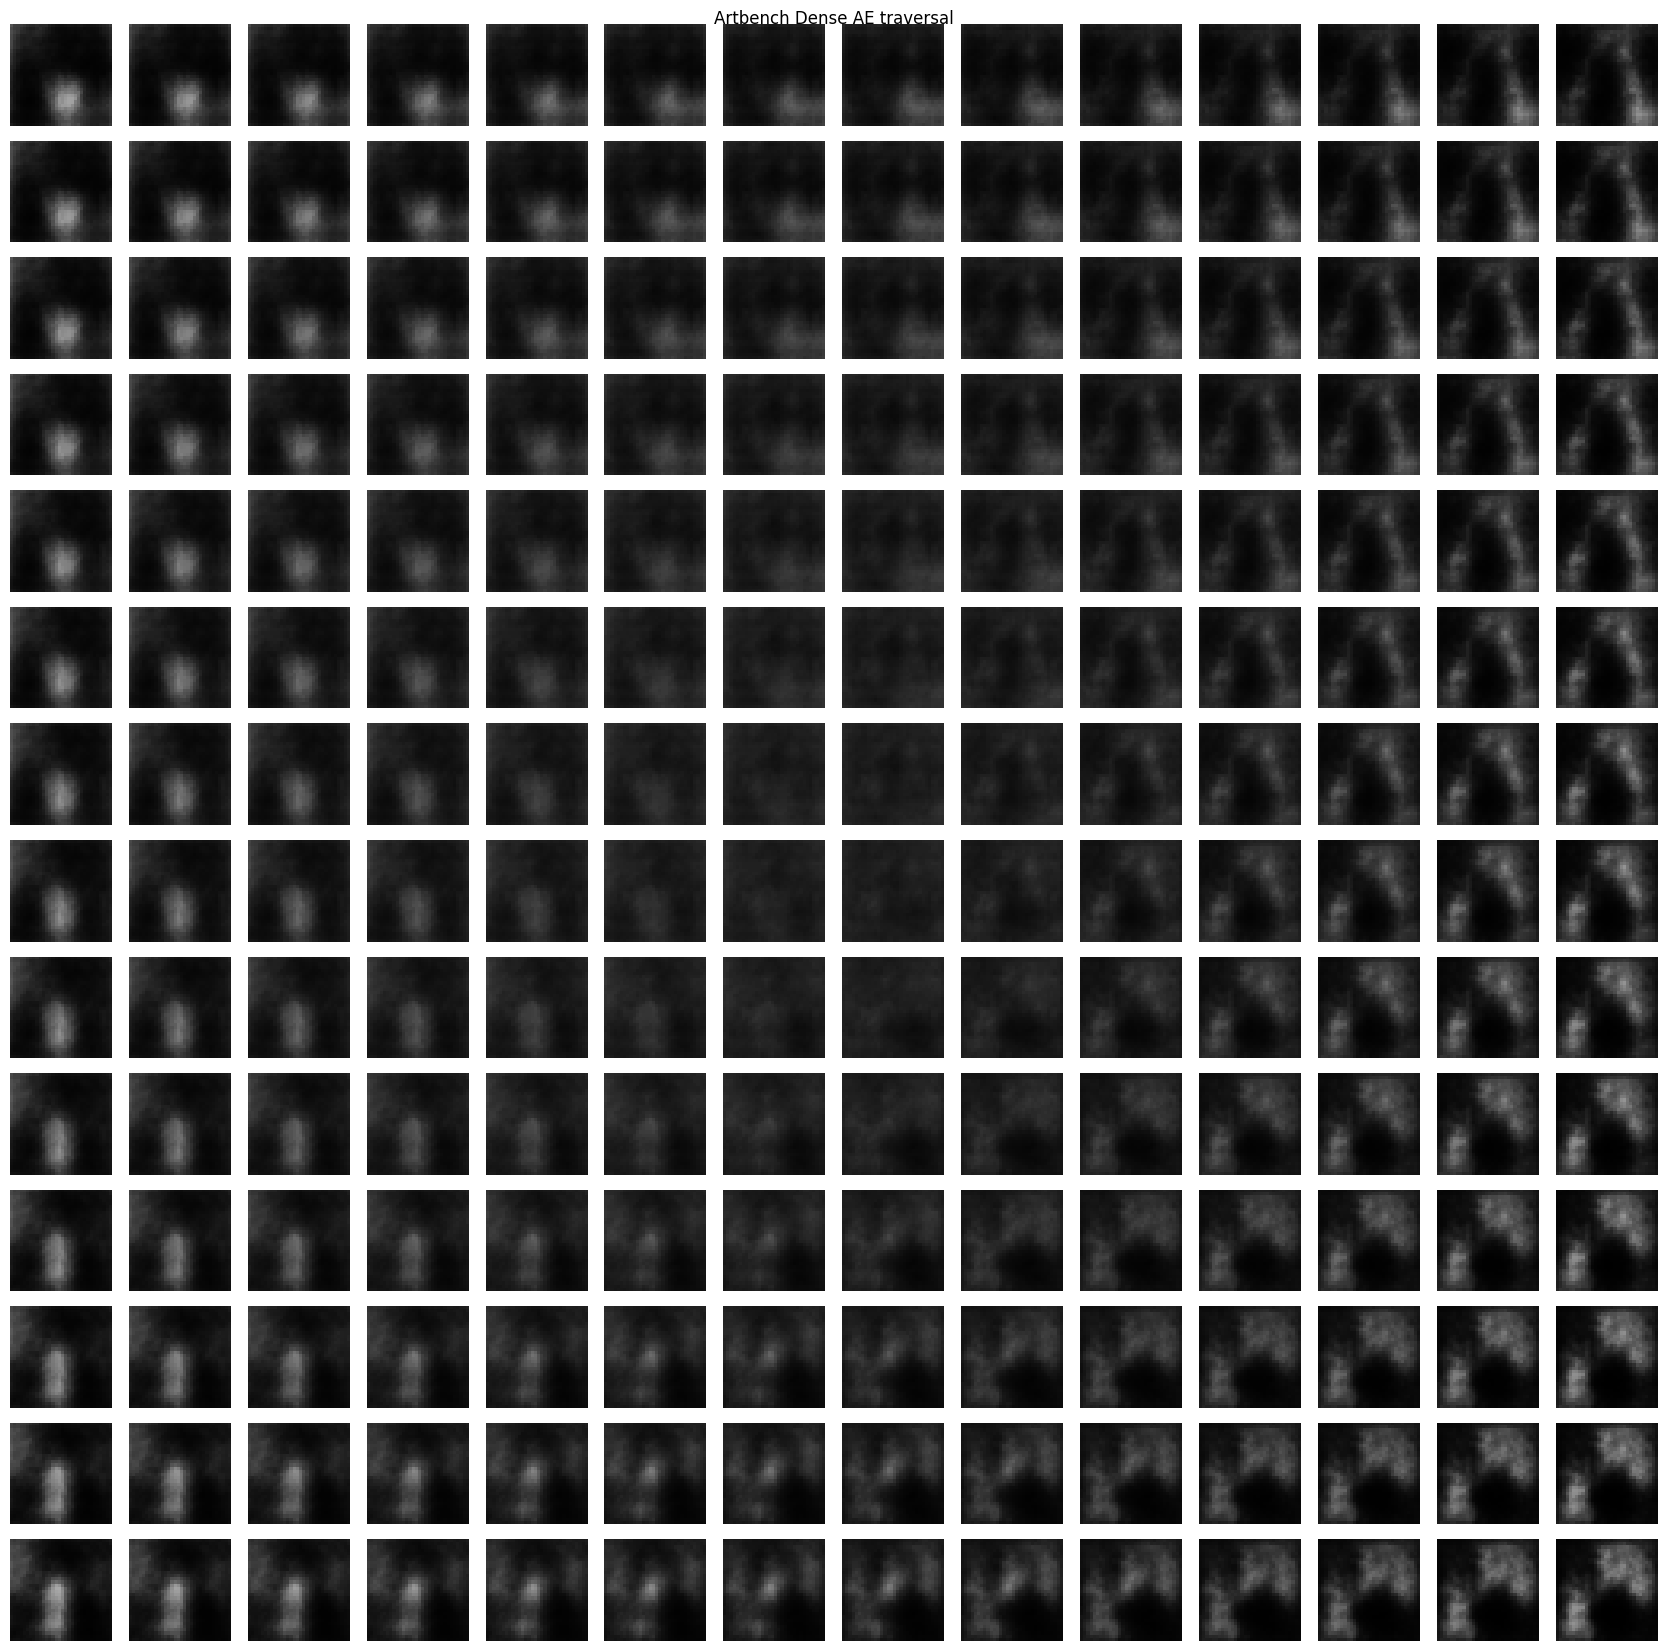

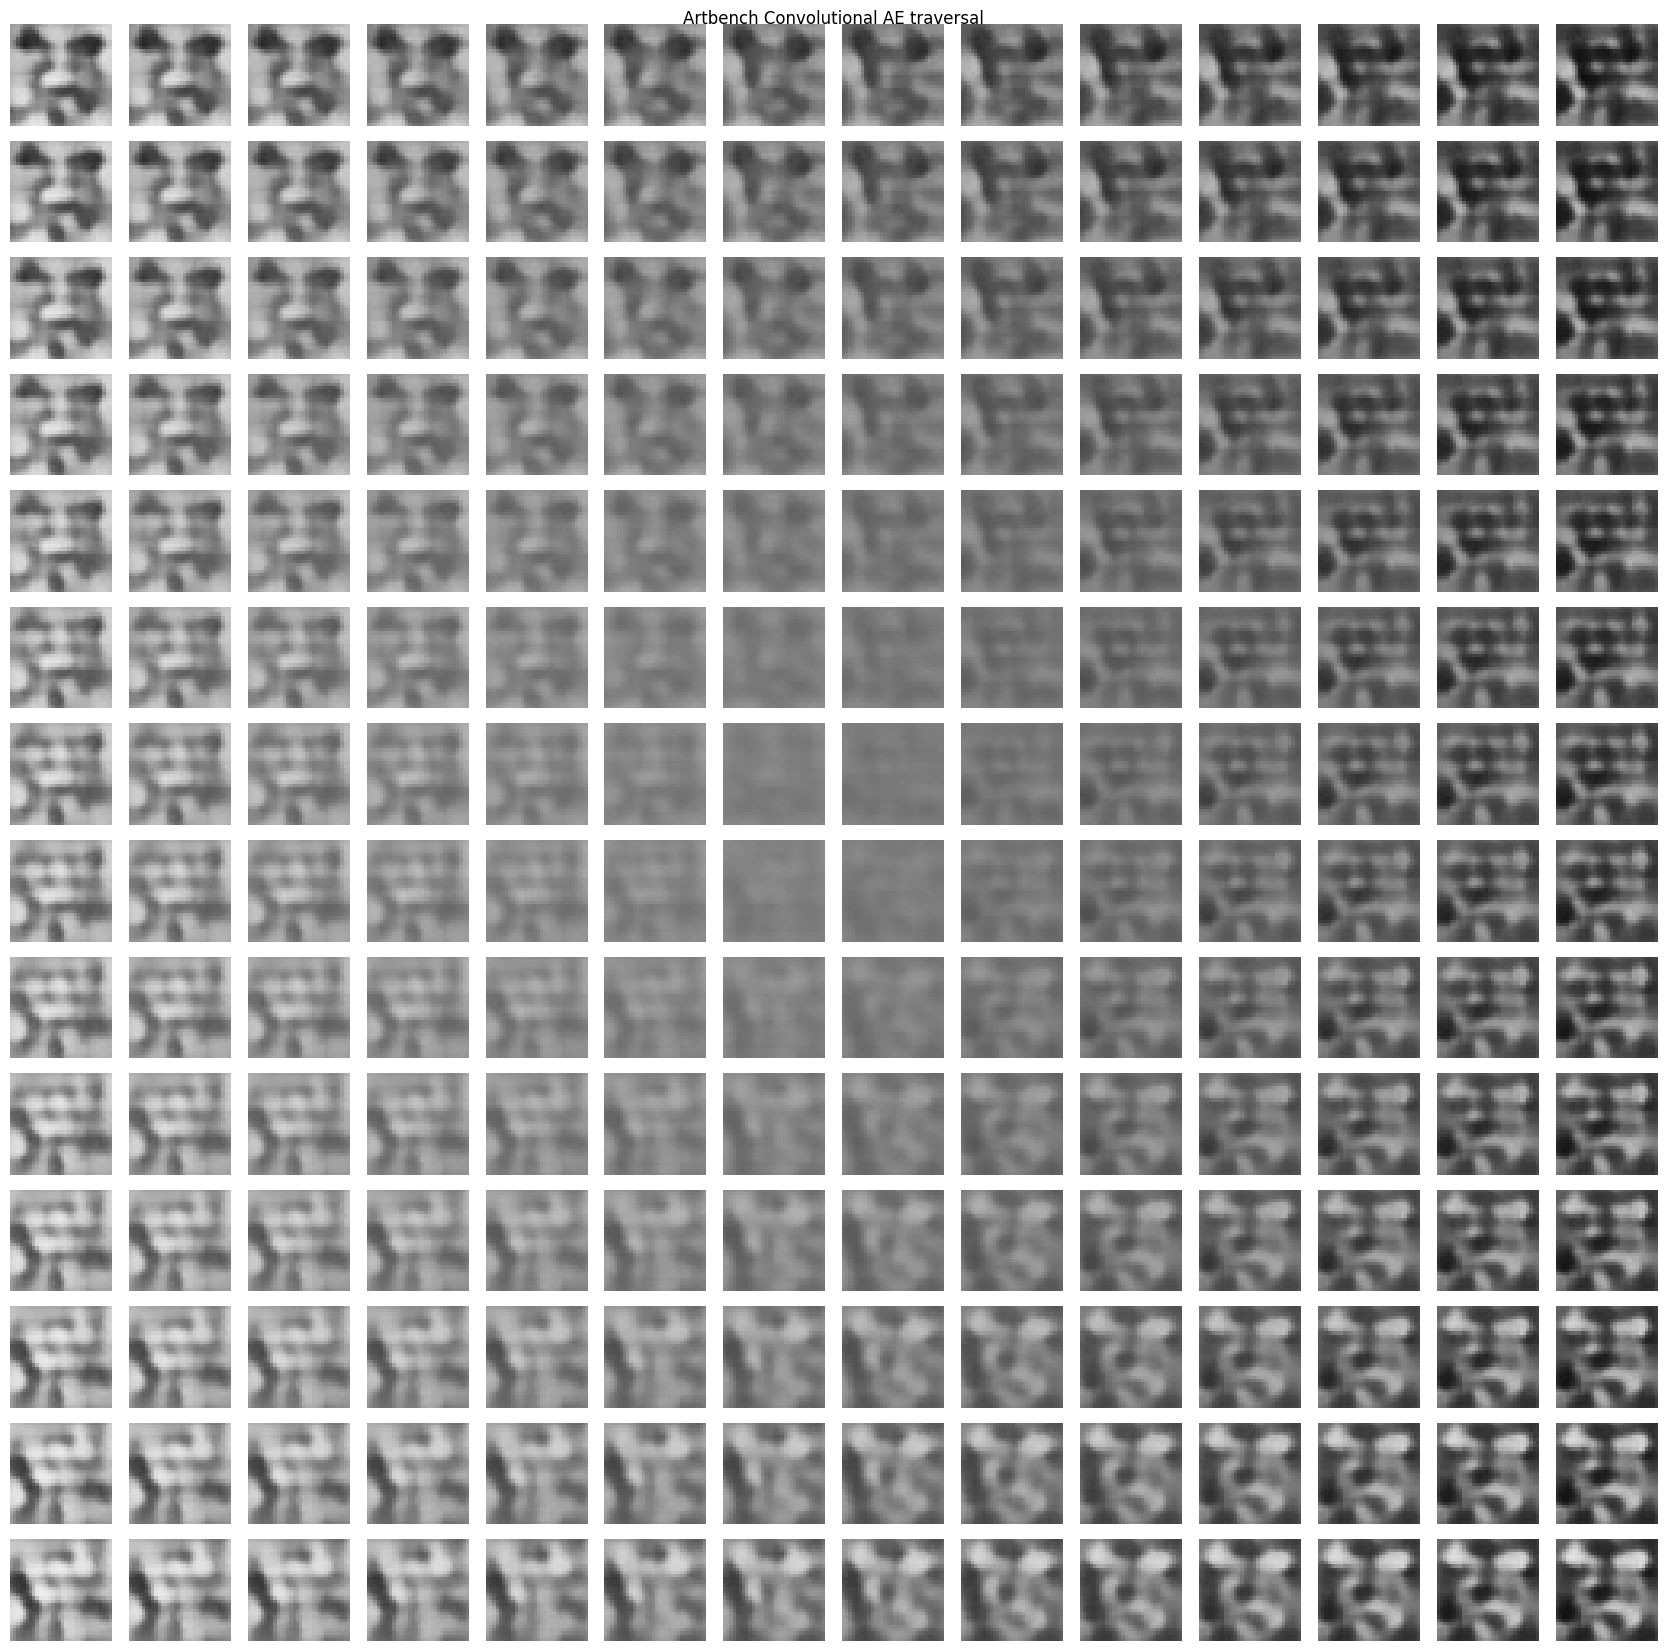

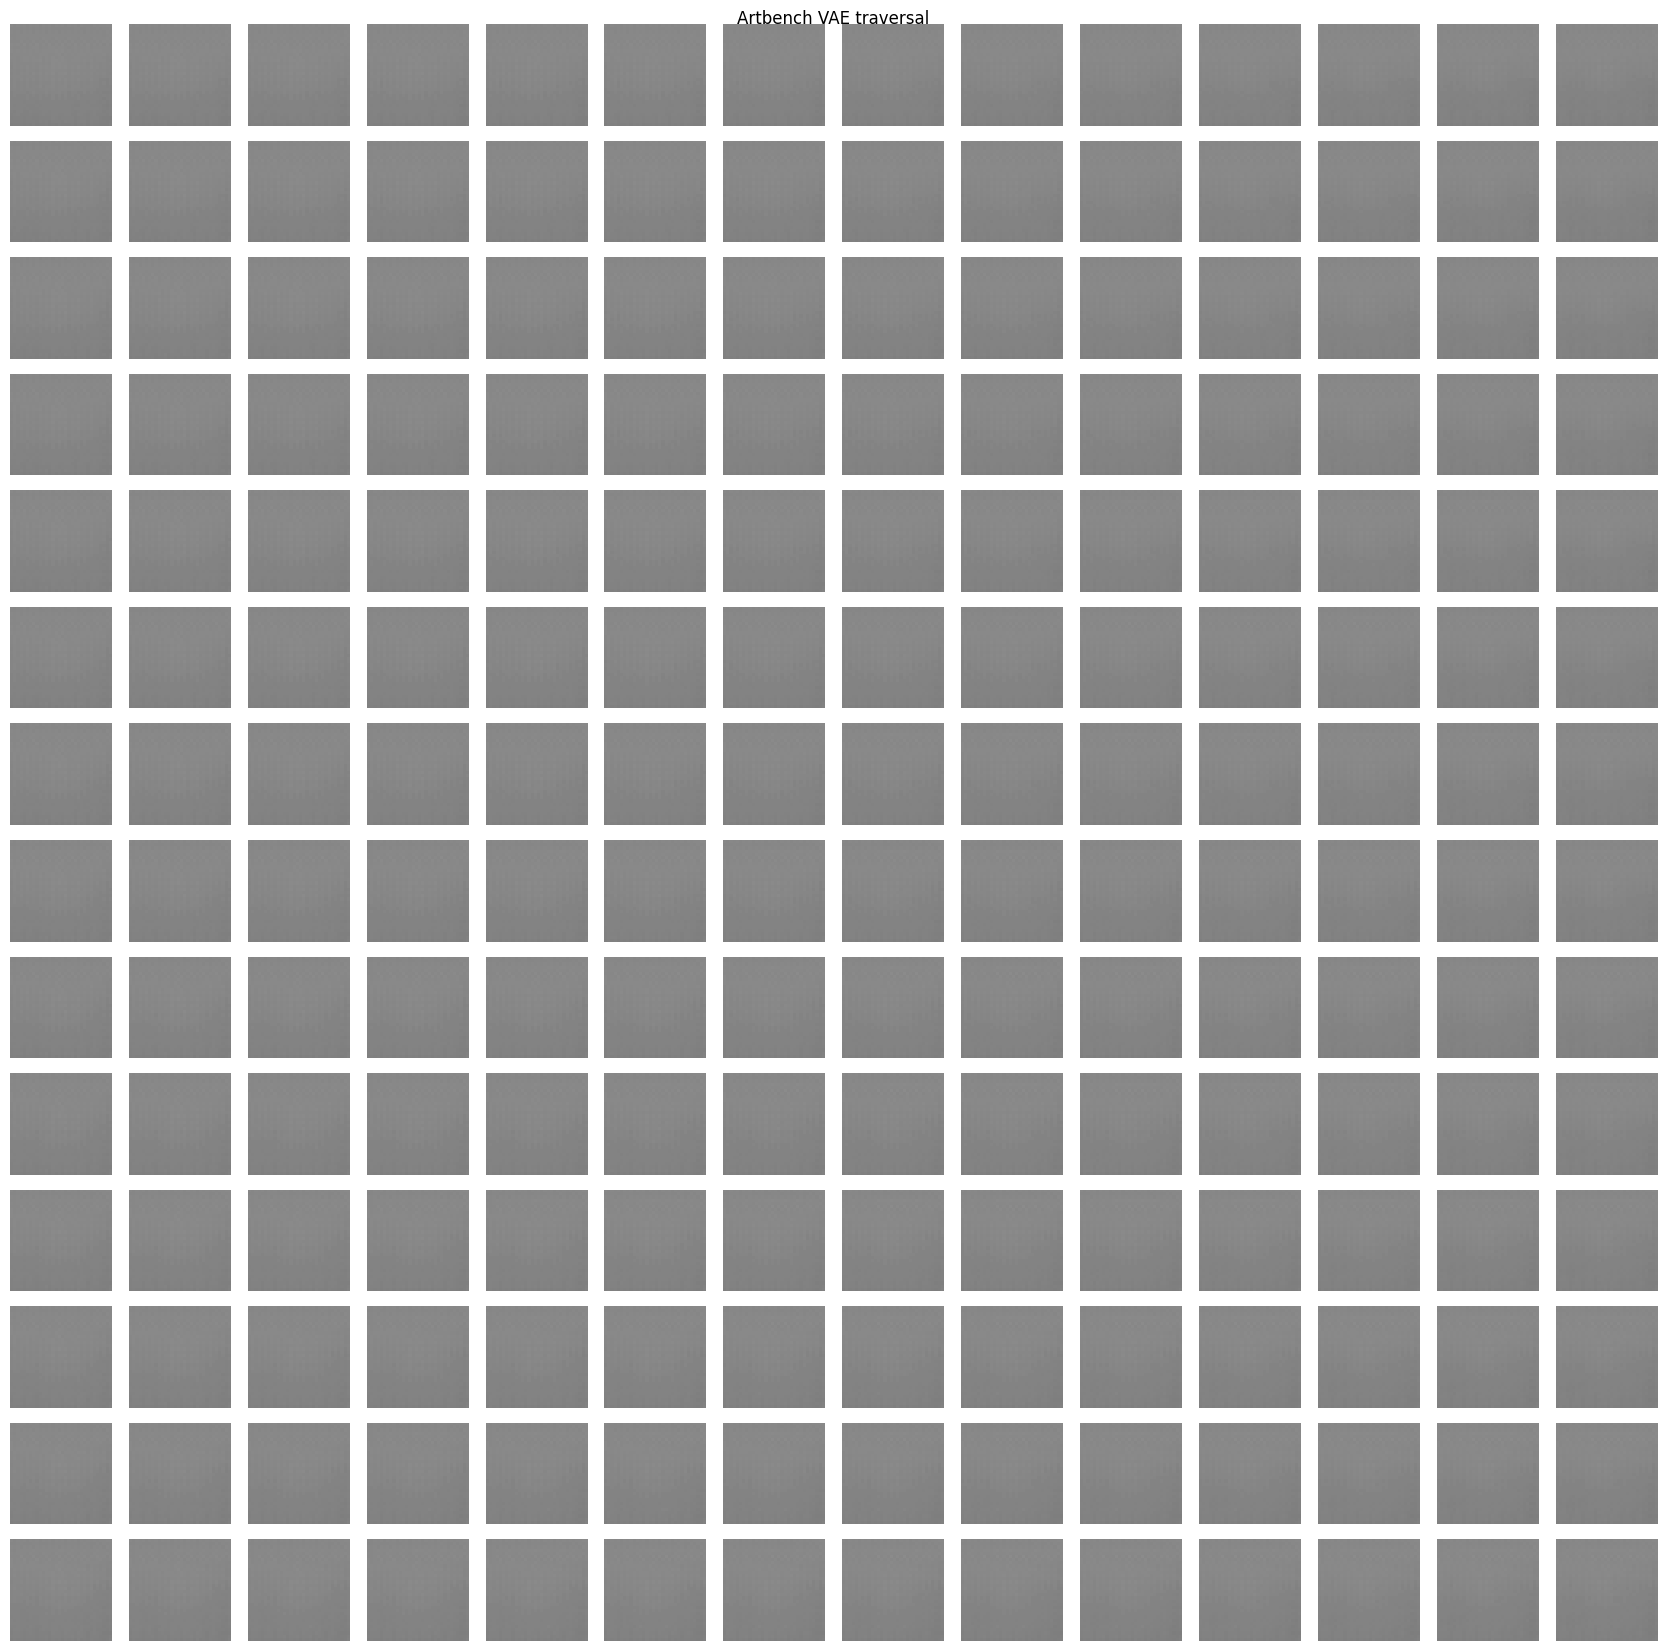

In [82]:
plot_latent_traversal(artbench_dense_decoder, title='Artbench Dense AE traversal', n_samples=200)
plot_latent_traversal(artbench_conv_decoder, title='Artbench Convolutional AE traversal', n_samples=200)
plot_latent_traversal(artbench_vae_decoder, title='Artbench VAE traversal', n_samples=200)

In [83]:
ARTBENCH_LABELS = {i: name for i, name in enumerate(class_names)}


def pick_transition_pair(loader, start_label=0, end_label=9, max_scan_batches=80):
    xs, ys = [], []
    for bi, (x, y, _) in enumerate(loader):
        xs.append(x)
        ys.append(y)
        if bi + 1 >= max_scan_batches:
            break

    x_all = torch.cat(xs, dim=0)
    y_all = torch.cat(ys, dim=0)

    def first_index_for_label(lbl):
        idx = torch.where(y_all == lbl)[0]
        if idx.numel() == 0:
            raise ValueError(f'Label {lbl} not found in scanned batches.')
        return int(idx[0].item())

    idx_a = 0 if start_label is None else first_index_for_label(start_label)

    if end_label is None:
        if x_all.size(0) < 2:
            raise ValueError('Need at least 2 samples to build a transition pair.')
        idx_b = 1 if idx_a == 0 else 0
    else:
        idx_b = first_index_for_label(end_label)
        if idx_b == idx_a:
            idx_alt = torch.where(y_all == end_label)[0]
            if idx_alt.numel() > 1:
                idx_b = int(idx_alt[1].item())

    x_a = x_all[idx_a:idx_a + 1]
    x_b = x_all[idx_b:idx_b + 1]
    y_a = int(y_all[idx_a].item())
    y_b = int(y_all[idx_b].item())
    return x_a, y_a, x_b, y_b


def encode_for_transition(model, x, use_vae_mu=True):
    z_enc = model.encode(x)
    if isinstance(z_enc, tuple):
        mu, logvar = z_enc
        if use_vae_mu:
            return mu
        return model.reparameterize(mu, logvar)
    return z_enc


def plot_latent_transition_between_samples(
    model,
    loader,
    title='Latent transition',
    n_steps=25,
    start_label=0,
    end_label=9,
    use_vae_mu=True,
):
    model.eval()
    x_a, y_a, x_b, y_b = pick_transition_pair(loader, start_label=start_label, end_label=end_label)

    x_a_dev = x_a.to(device)
    x_b_dev = x_b.to(device)

    with torch.no_grad():
        z_a = encode_for_transition(model, x_a_dev, use_vae_mu=use_vae_mu)
        z_b = encode_for_transition(model, x_b_dev, use_vae_mu=use_vae_mu)

        alphas = torch.linspace(0.0, 1.0, n_steps, device=device).unsqueeze(1)
        z_path = (1.0 - alphas) * z_a + alphas * z_b
        x_path = model.decode(z_path).clamp(0, 1).cpu()

    fig, axes = plt.subplots(2, n_steps, figsize=(1.15 * n_steps, 3.1))

    for j in range(n_steps):
        img_decoded = x_path[j].permute(1, 2, 0).numpy()
        axes[1, j].imshow(img_decoded)
        axes[1, j].axis('off')
        if j in (0, n_steps - 1):
            axes[1, j].set_title(f'alpha={j/(n_steps-1):.2f}', fontsize=8)

    axes[0, 0].imshow(x_a[0, 0], cmap='gray')
    axes[0, 0].set_title(f'start: {ARTBENCH_LABELS.get(y_a, y_a)}', fontsize=9)
    axes[0, -1].imshow(x_b[0, 0], cmap='gray')
    axes[0, -1].set_title(f'end: {ARTBENCH_LABELS.get(y_b, y_b)}', fontsize=9)

    axes[0, 0].set_ylabel('real anchors')
    axes[1, 0].set_ylabel('decoded path')

    mode = 'mu path' if use_vae_mu else 'sampled path'
    plt.suptitle(f"{title} | {ARTBENCH_LABELS.get(y_a, y_a)} -> {ARTBENCH_LABELS.get(y_b, y_b)} | steps={n_steps} | {mode}")
    plt.tight_layout()
    plt.show()


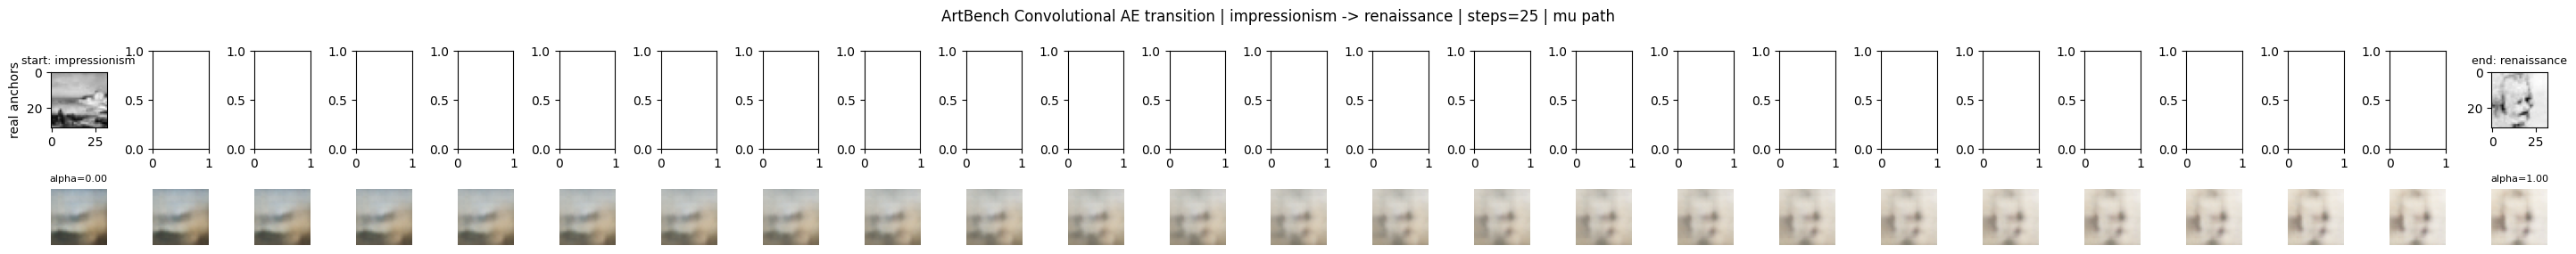

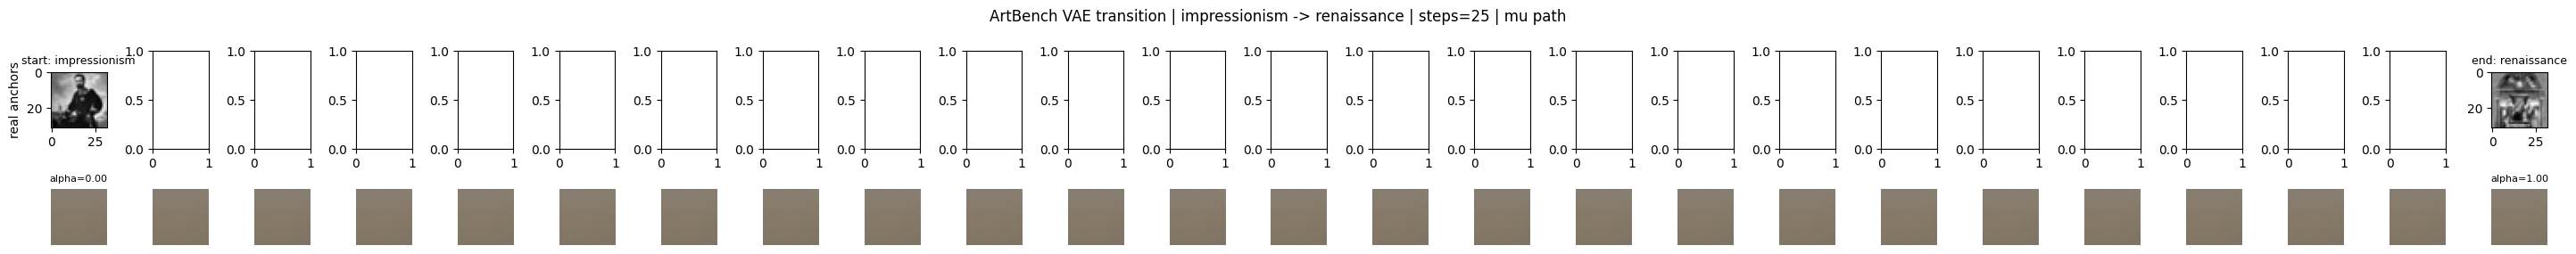

In [86]:
ARTBENCH_START_LABEL = 0
ARTBENCH_END_LABEL = 9
ARTBENCH_TRANSITION_STEPS = 25

plot_latent_transition_between_samples(
    conv_all,
    train_loader,
    title='ArtBench Convolutional AE transition',
    n_steps=ARTBENCH_TRANSITION_STEPS,
    start_label=ARTBENCH_START_LABEL,
    end_label=ARTBENCH_END_LABEL,
)

plot_latent_transition_between_samples(
    vae_all,
    train_loader,
    title='ArtBench VAE transition',
    n_steps=ARTBENCH_TRANSITION_STEPS,
    start_label=ARTBENCH_START_LABEL,
    end_label=ARTBENCH_END_LABEL,
    use_vae_mu=True,
)

## FID

In [88]:
def to_uint8_3ch(x):
    x = x.clamp(0, 1)
    x = (x * 255.0).to(torch.uint8)
    return x


def collect_real_images(loader, n_samples=500):
    xs, count = [], 0
    for x, _, _ in loader:
        xs.append(x)
        count += x.size(0)
        if count >= n_samples:
            break
    return torch.cat(xs, dim=0)[:n_samples]


def sample_from_conv_empirical_latent(model, loader, n_samples=500):
    model.eval()
    zs, count = [], 0
    with torch.no_grad():
        for x, _, _ in loader:
            x = x.to(device)
            z = model.encode(x)
            zs.append(z.cpu())
            count += z.size(0)
            if count >= max(n_samples, 2000):
                break
    z_all = torch.cat(zs, dim=0)
    z = z_all[torch.randperm(z_all.size(0))[:n_samples]].to(device)
    with torch.no_grad():
        xhat = model.decode(z).cpu().clamp(0, 1)
    return xhat


def sample_from_vae_prior(model, n_samples=500):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, model.latent_dim, device=device)
        xhat = model.decode(z).cpu().clamp(0, 1)
    return xhat


In [89]:
N_FID_SAMPLES = 200  

fid_use_cuda = torch.cuda.is_available()

real_imgs = collect_real_images(train_loader, n_samples=N_FID_SAMPLES)
conv_gen = sample_from_conv_empirical_latent(conv_all, train_loader, n_samples=N_FID_SAMPLES)
vae_gen = sample_from_vae_prior(vae_all, n_samples=N_FID_SAMPLES)

real_u8 = to_uint8_3ch(real_imgs)
conv_u8 = to_uint8_3ch(conv_gen)
vae_u8 = to_uint8_3ch(vae_gen)

import importlib
import subprocess
import sys
import tempfile
from pathlib import Path
from PIL import Image


def save_uint8_batch_to_dir(batch_u8, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for i in range(batch_u8.size(0)):
        arr = batch_u8[i].permute(1, 2, 0).cpu().numpy()
        Image.fromarray(arr).save(out_dir / f'{i:05d}.png')


def compute_fid_with_torch_fidelity(real_batch_u8, gen_batch_u8, use_cuda=False):
    try:
        import torch_fidelity
    except Exception:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torch-fidelity>=0.3,<1.0'])
        importlib.invalidate_caches()
        import torch_fidelity

    with tempfile.TemporaryDirectory() as tmpdir:
        real_dir = Path(tmpdir) / 'real'
        gen_dir = Path(tmpdir) / 'gen'
        save_uint8_batch_to_dir(real_batch_u8, real_dir)
        save_uint8_batch_to_dir(gen_batch_u8, gen_dir)

        metrics = torch_fidelity.calculate_metrics(
            input1=str(real_dir),
            input2=str(gen_dir),
            cuda=bool(use_cuda),
            fid=True,
            isc=False,
            kid=False,
            verbose=False,
        )
    return float(metrics['frechet_inception_distance'])


fid_conv = compute_fid_with_torch_fidelity(real_u8, conv_u8, use_cuda=fid_use_cuda)
fid_vae = compute_fid_with_torch_fidelity(real_u8, vae_u8, use_cuda=fid_use_cuda)

print(f'FID backend: torch-fidelity')
print(f'FID device: {"cuda" if fid_use_cuda else "cpu"}')
print(f'FID Convolutional AE (n={N_FID_SAMPLES}): {fid_conv:.4f}')
print(f'FID VAE             (n={N_FID_SAMPLES}): {fid_vae:.4f}')


FID backend: torch-fidelity
FID device: cpu
FID Convolutional AE (n=200): 248.3307
FID VAE             (n=200): 469.1409
